# Task 2: Quantitative Analysis - Sentiment Analysis

In this task, we quantify the sentiment of financial news headlines using modular functions from our `scripts` folder. This data will be saved for correlation analysis in Task 3.

In [ ]:

%pip install pandas matplotlib seaborn nltk textblob vaderSentiment

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add project root to path
sys.path.append('..')
from scripts.sentiment_utils import get_vader_score, get_textblob_score, label_sentiment

# Set plotting style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

print("Setup successful!")

Setup successful!


In [3]:
# Data Loading
data_path = '../data/raw/raw_analyst_ratings.csv'
if not os.path.exists(data_path):
    data_path = 'data/raw/raw_analyst_ratings.csv'

df = pd.read_csv(data_path)
print(f"Loaded {df.shape[0]} headlines.")

Loaded 1407328 headlines.


## 1. Modular Sentiment Analysis
Applying VADER and TextBlob scoring using helper functions.

In [4]:
print("Calculating Sentiment Scores (this may take a few minutes)... ")

# Apply VADER (Compound score)
df['vader_compound'] = df['headline'].apply(get_vader_score)

# Apply TextBlob (Polarity score)
df['textblob_polarity'] = df['headline'].apply(get_textblob_score)

# Label Sentiment
df['sentiment'] = df['vader_compound'].apply(label_sentiment)

print("Analysis complete!")

Calculating Sentiment Scores (this may take a few minutes)... 
Analysis complete!


## 2. Sentiment Distribution
Visualizing the overall tone of the financial news.

Sentiment distribution counts:
sentiment
Neutral     739332
Positive    442936
Negative    225060
Name: count, dtype: int64


C:\Users\acer\AppData\Local\Temp\ipykernel_24300\3147350845.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='RdYlGn', order=['Negative', 'Neutral', 'Positive'])


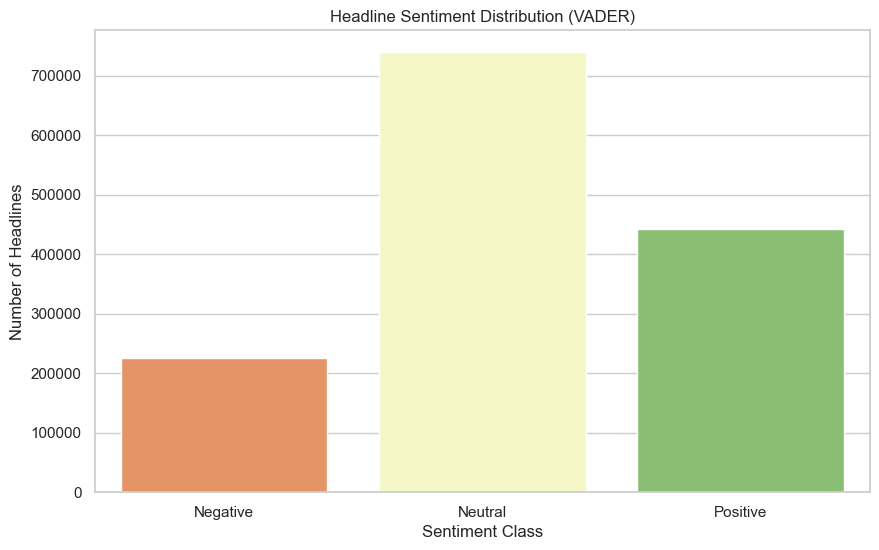

In [5]:
print("Sentiment distribution counts:")
print(df['sentiment'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=df, palette='RdYlGn', order=['Negative', 'Neutral', 'Positive'])
plt.title('Headline Sentiment Distribution (VADER)')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Headlines')
plt.show()

## 3. Saving Enriched Data
Saving the dataset for price correlation analysis.

In [6]:
output_path = '../data/processed/headlines_with_sentiment.csv'
os.makedirs('../data/processed', exist_ok=True)
df.to_csv(output_path, index=False)
print(f"Saved results to {output_path}")

Saved results to ../data/processed/headlines_with_sentiment.csv
